In [1]:
# Shared raw data in repository; generated data in this study
from pathlib import Path
import sys

REPO_ROOT = next(
    (p for p in (Path.cwd(), *Path.cwd().parents)
     if (p / "setup-env.ps1").is_file() and (p / "study_with_me").is_dir()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Run this notebook from inside jepx-data-analytics.")
PROJECT_DIR = REPO_ROOT / "study_with_me"
RAW_DATA_DIR = REPO_ROOT / "data" / "raw"
PROJECT_DATA_DIR = PROJECT_DIR / "data"
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import sys
import os

sys.path.append(os.path.abspath(".."))

import src.load_csv as lc
import src.make_dateset as md

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy
import sklearn

import pymc as pm
import arviz as az
import pytensor

print("numpy:",np.__version__)
print("pandas:",pd.__version__)
print("matplotlib:",matplotlib.__version__)
print("scipy:",scipy.__version__)
print("sklearn:",sklearn.__version__)

print("pymc:", pm.__version__)
print("arviz:", az.__version__)
print("pytensor:", pytensor.__version__)

numpy: 2.4.2
pandas: 3.0.1
matplotlib: 3.10.8
scipy: 1.17.1
sklearn: 1.8.0
pymc: 5.28.2
arviz: 0.23.4
pytensor: 2.38.2


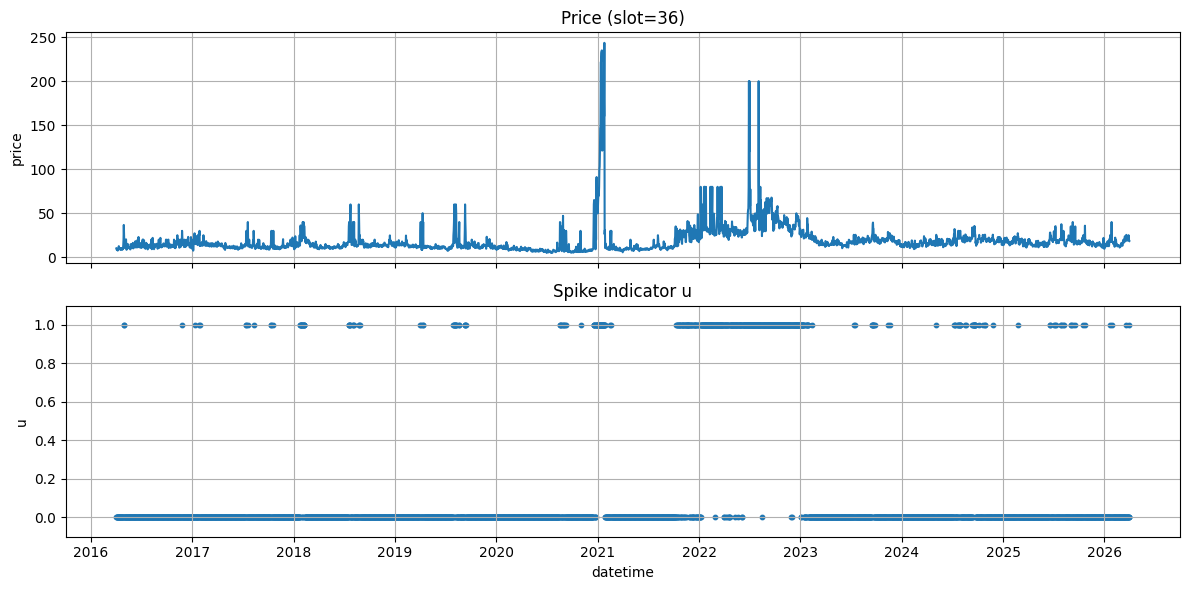

In [3]:
import src.util_plot as uplt
df_tokyo = pd.read_csv((PROJECT_DATA_DIR / "process/electricity/df_tokyo.csv"), parse_dates=True, index_col=0)

uplt.plot_price_and_u(
    df=df_tokyo,
    slot=36
)

In [4]:
df_tokyo.head()

,slot,is_holiday,price,price_scaled,u,x
datetime,,,,,,
2016-04-01 00:00:00,1,False,6.69,6.69,0,0.0
2016-04-01 00:30:00,2,False,6.34,6.34,0,0.0
2016-04-01 01:00:00,3,False,6.34,6.34,0,0.0
2016-04-01 01:30:00,4,False,6.03,6.03,0,0.0
2016-04-01 02:00:00,5,False,6.57,6.57,0,0.0


In [5]:
df_tokyo.tail()

,slot,is_holiday,price,price_scaled,u,x
datetime,,,,,,
2026-03-31 21:30:00,44,False,21.21,21.21,0,0.0
2026-03-31 22:00:00,45,False,21.00,21.00,0,0.0
2026-03-31 22:30:00,46,False,20.50,20.50,0,0.0
2026-03-31 23:00:00,47,False,20.20,20.20,0,0.0
2026-03-31 23:30:00,48,False,19.70,19.70,0,0.0
